In [1]:
# Connect Google Drive with Colab

from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
import os

project_path = "/content/drive/MyDrive/Traffic_Sign_Project/Traffic_Sign_Project"

print(os.listdir(project_path))

['PRAICP-1002-TrafSignDetc.zip']


In [4]:
# Create a folder for extracted dataset

import zipfile
import os

zip_path = "/content/drive/MyDrive/Traffic_Sign_Project/Traffic_Sign_Project/PRAICP-1002-TrafSignDetc.zip"

extract_path = "/content/traffic_sign_data"

# Extract zip file

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset extracted successfully!")

Dataset extracted successfully!


In [5]:
# check Extracted Files
import os

print(os.listdir("/content/traffic_sign_data"))

['test', 'Meta', 'train', 'Train', 'Test', 'Meta.csv', 'Train.csv', 'Test.csv', 'meta']


In [6]:
# Import pandas

import pandas as pd

# Load CSV files

train_df = pd.read_csv("/content/traffic_sign_data/Train.csv")
test_df = pd.read_csv("/content/traffic_sign_data/Test.csv")
meta_df = pd.read_csv("/content/traffic_sign_data/Meta.csv")

# Display first 5 rows

print("Train Data")
display(train_df.head())

print("Test Data")
display(test_df.head())

print("Meta Data")
display(meta_df.head())

Train Data


,Width,Height,Roi.X1,Roi.Y1,Roi.X2,Roi.Y2,ClassId,Path
0,27,26,5,5,22,20,20,Train/20/00020_00000_00000.png
1,28,27,5,6,23,22,20,Train/20/00020_00000_00001.png
2,29,26,6,5,24,21,20,Train/20/00020_00000_00002.png
3,28,27,5,6,23,22,20,Train/20/00020_00000_00003.png
4,28,26,5,5,23,21,20,Train/20/00020_00000_00004.png


Test Data


,Width,Height,Roi.X1,Roi.Y1,Roi.X2,Roi.Y2,ClassId,Path
0,53,54,6,5,48,49,16,Test/00000.png
1,42,45,5,5,36,40,1,Test/00001.png
2,48,52,6,6,43,47,38,Test/00002.png
3,27,29,5,5,22,24,33,Test/00003.png
4,60,57,5,5,55,52,11,Test/00004.png


Meta Data


,Path,ClassId,ShapeId,ColorId,SignId
0,Meta/27.png,27,0,0,1.32
1,Meta/0.png,0,1,0,3.29
2,Meta/1.png,1,1,0,3.29
3,Meta/10.png,10,1,0,3.27
4,Meta/11.png,11,0,0,1.22


In [ ]:
# Dataset Overview

In [7]:
# Dataset overview

print("Training Samples :", len(train_df))
print("Testing Samples  :", len(test_df))
print("Number of Classes:", train_df["ClassId"].nunique())

print("\nTrain Shape:", train_df.shape)
print("Test Shape :", test_df.shape)
print("Meta Shape :", meta_df.shape)

Training Samples : 39209
Testing Samples  : 12630
Number of Classes: 43

Train Shape: (39209, 8)
Test Shape : (12630, 8)
Meta Shape : (43, 5)


In [ ]:
# Missing Values Check

In [8]:
# Check missing values

print("Train Missing Values")
print(train_df.isnull().sum())

print("\nTest Missing Values")
print(test_df.isnull().sum())

print("\nMeta Missing Values")
print(meta_df.isnull().sum())

Train Missing Values
Width      0
Height     0
Roi.X1     0
Roi.Y1     0
Roi.X2     0
Roi.Y2     0
ClassId    0
Path       0
dtype: int64

Test Missing Values
Width      0
Height     0
Roi.X1     0
Roi.Y1     0
Roi.X2     0
Roi.Y2     0
ClassId    0
Path       0
dtype: int64

Meta Missing Values
Path       0
ClassId    0
ShapeId    0
ColorId    0
SignId     1
dtype: int64


In [ ]:
# Class Distribution Chart

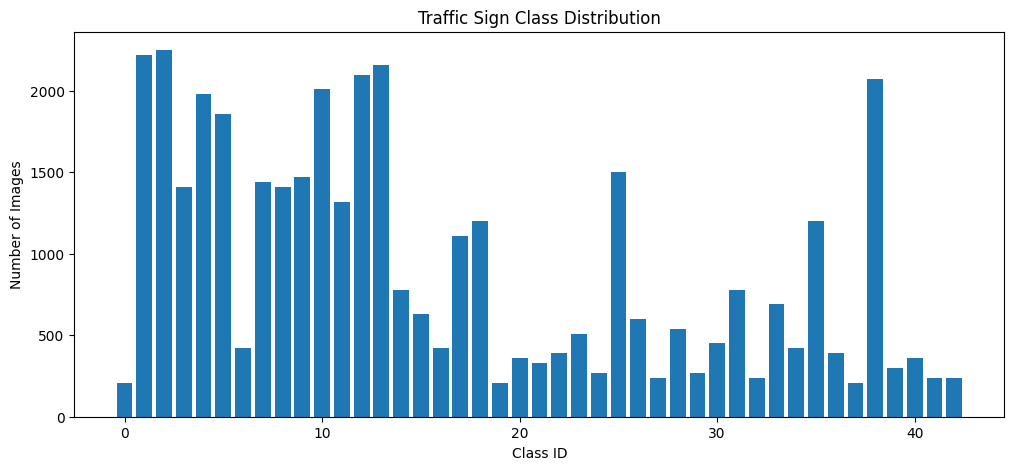

In [9]:
import matplotlib.pyplot as plt

# Count images in each class

class_counts = train_df["ClassId"].value_counts().sort_index()

# Plot

plt.figure(figsize=(12,5))
plt.bar(class_counts.index, class_counts.values)

plt.title("Traffic Sign Class Distribution")
plt.xlabel("Class ID")
plt.ylabel("Number of Images")

plt.show()

## Dataset Overview Observation

The dataset contains 39,209 training images and 12,630 testing images.

There are 43 different traffic sign classes, making this a multi-class image classification problem.

The dataset is sufficiently large for training deep learning models such as CNN and MobileNetV2.

The availability of a separate test dataset helps in evaluating model performance on unseen data.

Observation:

The dataset contains 43 traffic sign classes.

Some classes contain more images than others, indicating a slight class imbalance.

This imbalance may affect model learning and should be considered during model evaluation.

## Missing Values Observation

No missing values were found in the Train and Test datasets.

Only one missing value is present in the SignId column of the Meta dataset.

Since the Meta dataset is not directly used for model training, this missing value will not significantly affect model performance.

Overall, the dataset is clean and requires minimal preprocessing for missing values.

## EDA Section

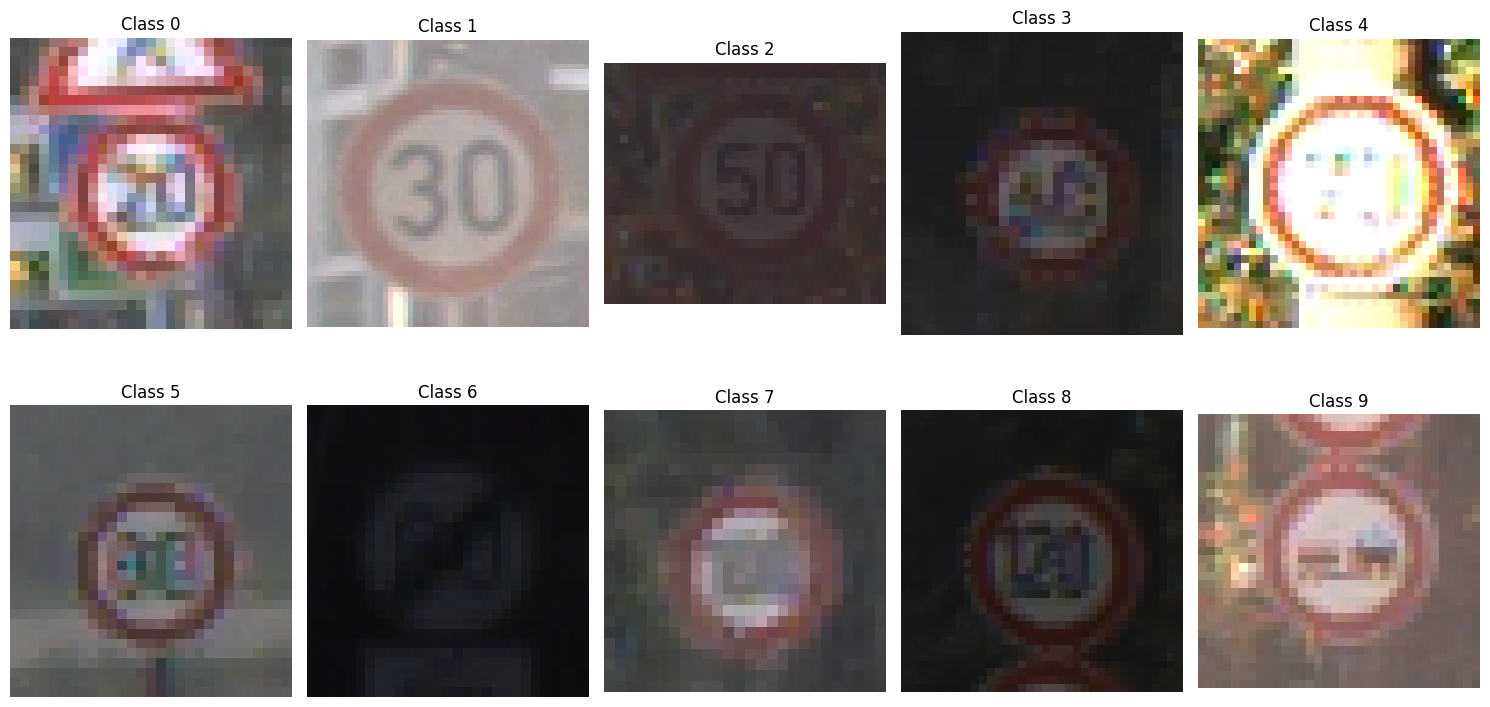

In [10]:
# Display Sample Images

# Import libraries
import cv2
import matplotlib.pyplot as plt

# Display one sample image from first 10 classes

plt.figure(figsize=(15,8))

for i in range(10):

    # Get first image path from class i
    image_path = train_df[train_df["ClassId"] == i]["Path"].iloc[0]

    # Full image path
    full_path = "/content/traffic_sign_data/" + image_path

    # Read image
    image = cv2.imread(full_path)

    # Convert BGR to RGB
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    # Plot image
    plt.subplot(2,5,i+1)
    plt.imshow(image)
    plt.title(f"Class {i}")
    plt.axis("off")

plt.tight_layout()
plt.show()


## Sample Image Observation

The traffic sign images vary in shape, color, and size.

Some classes have very similar visual patterns, making classification challenging.

The dataset contains circular, triangular, and rectangular traffic signs with different color combinations.

This diversity makes the dataset suitable for evaluating deep learning image classification models.

 ## EDA Section 3 (Image Size Analysis)

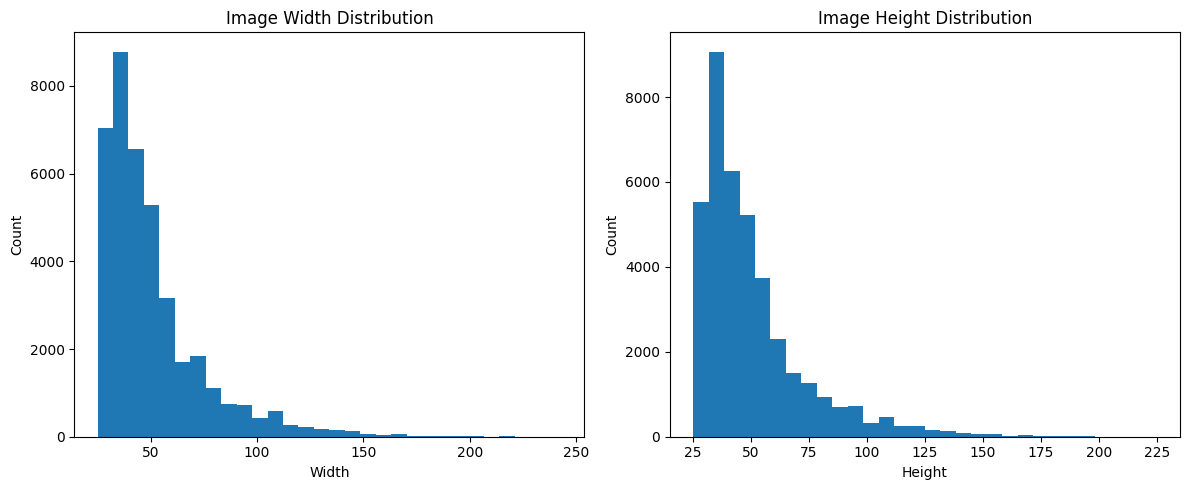

In [11]:
# Analyze image width and height

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.hist(train_df["Width"], bins=30)
plt.title("Image Width Distribution")
plt.xlabel("Width")
plt.ylabel("Count")

plt.subplot(1,2,2)
plt.hist(train_df["Height"], bins=30)
plt.title("Image Height Distribution")
plt.xlabel("Height")
plt.ylabel("Count")

plt.tight_layout()
plt.show()

## Image Size Observation

The dataset contains images of different dimensions.

Since deep learning models require fixed-size inputs, all images will be resized during preprocessing.

Resizing ensures consistency and enables efficient model training.

# EDA Section 4 : RGB Color Analysis

In [12]:
# Calculate average RGB values for first 10 classes

import numpy as np
import cv2

avg_red = []
avg_green = []
avg_blue = []

classes = range(10)

for class_id in classes:

    image_paths = train_df[train_df["ClassId"] == class_id]["Path"].head(20)

    reds = []
    greens = []
    blues = []

    for path in image_paths:

        img = cv2.imread("/content/traffic_sign_data/" + path)

        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        reds.append(np.mean(img[:,:,0]))
        greens.append(np.mean(img[:,:,1]))
        blues.append(np.mean(img[:,:,2]))

    avg_red.append(np.mean(reds))
    avg_green.append(np.mean(greens))
    avg_blue.append(np.mean(blues))

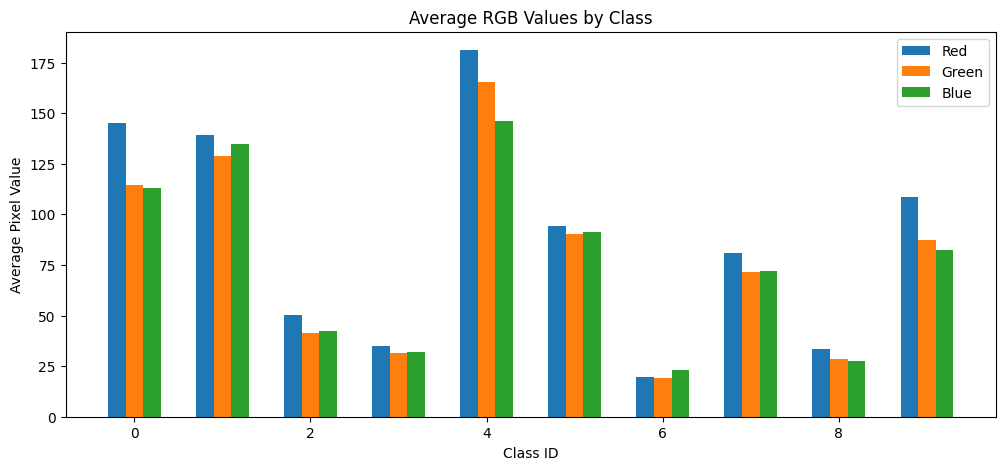

In [13]:
# Plot average RGB values

import matplotlib.pyplot as plt

x = np.arange(len(classes))

plt.figure(figsize=(12,5))

plt.bar(x-0.2, avg_red, width=0.2, label="Red")
plt.bar(x, avg_green, width=0.2, label="Green")
plt.bar(x+0.2, avg_blue, width=0.2, label="Blue")

plt.xlabel("Class ID")
plt.ylabel("Average Pixel Value")
plt.title("Average RGB Values by Class")

plt.legend()

plt.show()

## RGB Analysis Observation

Different traffic sign classes exhibit different color characteristics.

Red color dominates warning and prohibition signs, while blue and white colors are common in mandatory signs.

Color information is expected to play an important role in traffic sign classification.

## EDA Section 5 : Pixel Intensity Distribution

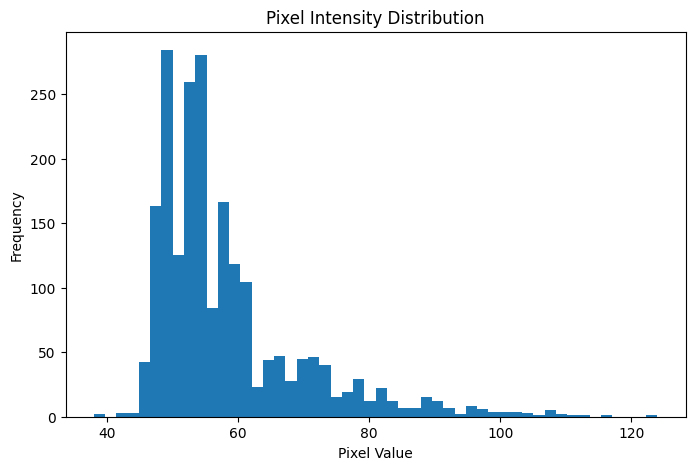

In [14]:
# Pixel intensity distribution

sample_image_path = "/content/traffic_sign_data/" + train_df["Path"].iloc[0]

img = cv2.imread(sample_image_path)

img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(8,5))

plt.hist(img.ravel(), bins=50)

plt.title("Pixel Intensity Distribution")
plt.xlabel("Pixel Value")
plt.ylabel("Frequency")

plt.show()

# Data Preprocessing

In this section, images are loaded, resized, normalized, and converted into a format suitable for deep learning models.

In [15]:
# Libraries for image processing

import numpy as np
import cv2

# Libraries for label encoding

from tensorflow.keras.utils import to_categorical

In [16]:
# Create empty lists

images = []
labels = []

# Loop through all training images

for index, row in train_df.iterrows():

    # Full image path
    image_path = "/content/traffic_sign_data/" + row["Path"]

    # Read image
    image = cv2.imread(image_path)

    # Resize image to fixed size
    image = cv2.resize(image, (30, 30))

    # Store image
    images.append(image)

    # Store class label
    labels.append(row["ClassId"])

print("Images loaded successfully")

Images loaded successfully


## Convert Lists to NumPy Arrays

In [17]:
# Convert into numpy arrays

X = np.array(images)
y = np.array(labels)

print("Image Shape :", X.shape)
print("Label Shape :", y.shape)

Image Shape : (39209, 30, 30, 3)
Label Shape : (39209,)


## Cell 18 : Normalize Images

In [18]:
# Scale pixel values between 0 and 1

X = X / 255.0

print("Normalization completed")

Normalization completed


## Normalization Observation

Pixel values originally ranged from 0 to 255.

Normalization scales the values to the range 0 to 1, which improves training stability and helps the neural network converge faster.

# One-Hot Encode Labels

In [19]:
# Convert class labels into categorical format

y = to_categorical(y, 43)

print("New Label Shape :", y.shape)

New Label Shape : (39209, 43)


## Label Encoding Observation

The dataset contains 43 traffic sign classes.

One-hot encoding converts each class label into a binary vector representation, making it suitable for multi-class classification.

# Train Validation Split

In [20]:
# Split data into training and validation sets

from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training Images :", X_train.shape)
print("Validation Images :", X_val.shape)

Training Images : (31367, 30, 30, 3)
Validation Images : (7842, 30, 30, 3)


# CNN Model

A Convolutional Neural Network (CNN) is used to classify traffic sign images.

The model consists of convolution layers, pooling layers, and fully connected layers.

In [21]:
# Import TensorFlow libraries

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D
from tensorflow.keras.layers import MaxPooling2D
from tensorflow.keras.layers import Flatten
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Dropout

In [22]:
# Create CNN model

cnn_model = Sequential()

# First convolution layer
cnn_model.add(Conv2D(32, (3,3), activation='relu',
                     input_shape=(30,30,3)))

# First pooling layer
cnn_model.add(MaxPooling2D(pool_size=(2,2)))

# Second convolution layer
cnn_model.add(Conv2D(64, (3,3), activation='relu'))

# Second pooling layer
cnn_model.add(MaxPooling2D(pool_size=(2,2)))

# Flatten layer
cnn_model.add(Flatten())

# Dense layer
cnn_model.add(Dense(128, activation='relu'))

# Dropout layer to reduce overfitting
cnn_model.add(Dropout(0.5))

# Output layer
cnn_model.add(Dense(43, activation='softmax'))

# Display model summary
cnn_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 12, 12, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2304)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       295,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 43)             │         5,547 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 319,979 (1.22 MB)

 Trainable params: 319,979 (1.22 MB)

 Non-trainable params: 0 (0.00 B)

In [23]:
# Compile CNN model

cnn_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [24]:
from tensorflow.keras.callbacks import EarlyStopping

# Stop training if validation loss does not improve

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

In [25]:
# Train CNN model

history_cnn = cnn_model.fit(
    X_train,
    y_train,
    epochs=15,
    batch_size=32,
    validation_data=(X_val, y_val),
    callbacks=[early_stop]
)

Epoch 1/15
981/981 ━━━━━━━━━━━━━━━━━━━━ 14s 8ms/step - accuracy: 0.5367 - loss: 1.6175 - val_accuracy: 0.8957 - val_loss: 0.4032
Epoch 2/15
981/981 ━━━━━━━━━━━━━━━━━━━━ 12s 4ms/step - accuracy: 0.8298 - loss: 0.5404 - val_accuracy: 0.9631 - val_loss: 0.1630
Epoch 3/15
981/981 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.8907 - loss: 0.3465 - val_accuracy: 0.9694 - val_loss: 0.1123
Epoch 4/15
981/981 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.9216 - loss: 0.2543 - val_accuracy: 0.9828 - val_loss: 0.0701
Epoch 5/15
981/981 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.9346 - loss: 0.2062 - val_accuracy: 0.9874 - val_loss: 0.0528
Epoch 6/15
981/981 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.9450 - loss: 0.1718 - val_accuracy: 0.9909 - val_loss: 0.0408
Epoch 7/15
981/981 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.9523 - loss: 0.1468 - val_accuracy: 0.9892 - val_loss: 0.0408
Epoch 8/15
981/981 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.9571 - loss: 0.1291 - val_accuracy: 

# Accuracy and Loss Graph

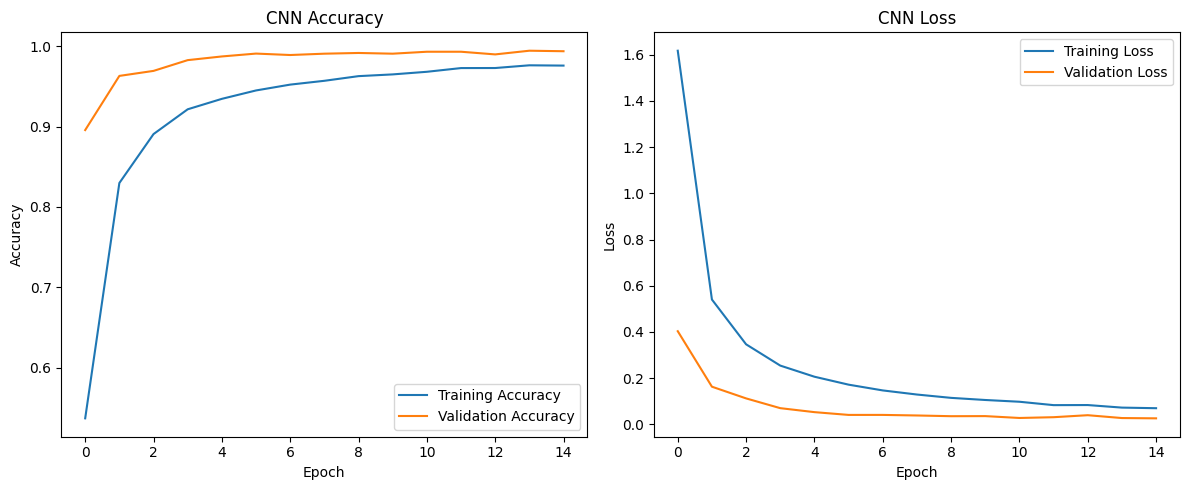

In [26]:
# Plot accuracy and loss curves

plt.figure(figsize=(12,5))

# Accuracy plot
plt.subplot(1,2,1)

plt.plot(history_cnn.history['accuracy'], label='Training Accuracy')
plt.plot(history_cnn.history['val_accuracy'], label='Validation Accuracy')

plt.title('CNN Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Loss plot
plt.subplot(1,2,2)

plt.plot(history_cnn.history['loss'], label='Training Loss')
plt.plot(history_cnn.history['val_loss'], label='Validation Loss')

plt.title('CNN Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()

plt.show()

## Training Observation

The CNN model showed continuous improvement during training.

Validation accuracy reached approximately 99.39%, indicating strong generalization capability.

Both training and validation losses decreased consistently, suggesting minimal overfitting.

# Predictions on Validation Set

In [27]:
# Predict validation images

y_pred = cnn_model.predict(X_val)

# Convert probabilities into class labels

y_pred_classes = np.argmax(y_pred, axis=1)

# Convert one-hot labels into original labels

y_true = np.argmax(y_val, axis=1)

246/246 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


In [28]:
# Classification Report
from sklearn.metrics import classification_report

print(classification_report(y_true, y_pred_classes))

              precision    recall  f1-score   support

           0       1.00      0.98      0.99        42
           1       1.00      0.99      0.99       444
           2       0.99      0.99      0.99       450
           3       0.97      0.99      0.98       282
           4       0.99      1.00      0.99       396
           5       0.99      0.97      0.98       372
           6       1.00      0.99      0.99        84
           7       1.00      1.00      1.00       288
           8       0.99      0.99      0.99       282
           9       1.00      0.99      0.99       294
          10       1.00      1.00      1.00       402
          11       0.99      1.00      0.99       264
          12       1.00      1.00      1.00       420
          13       1.00      1.00      1.00       432
          14       1.00      1.00      1.00       156
          15       0.98      0.99      0.98       126
          16       1.00      1.00      1.00        84
          17       1.00    

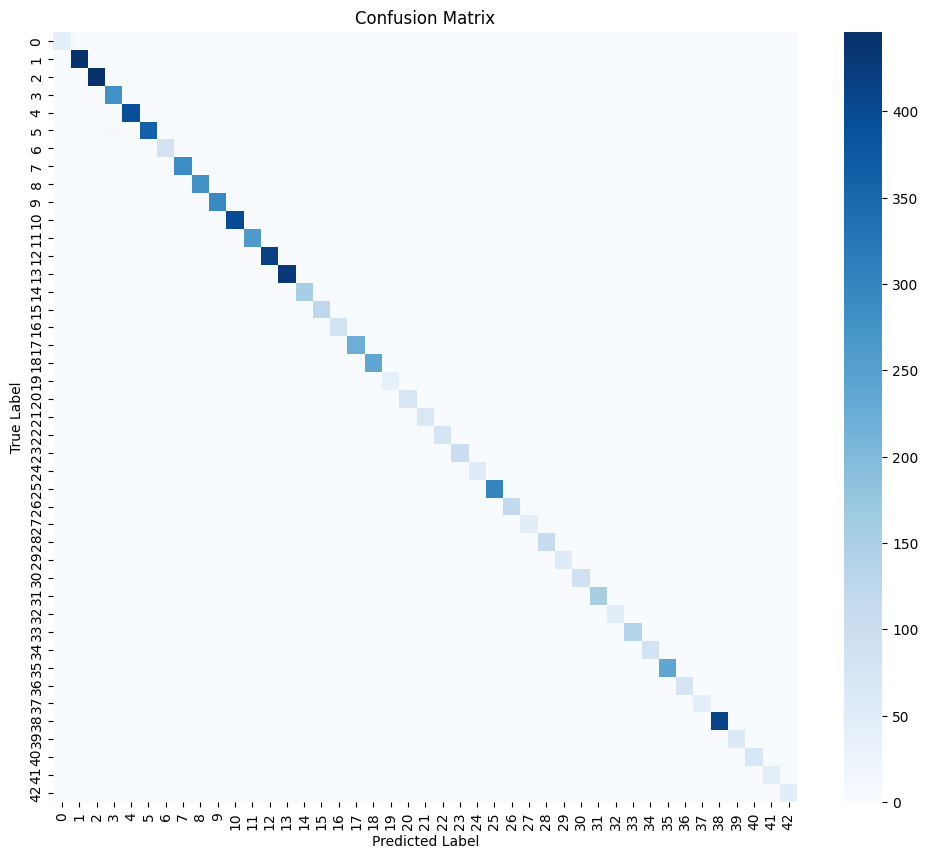

In [29]:
# Confusion Matrix

from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_true, y_pred_classes)

plt.figure(figsize=(12,10))

sns.heatmap(cm,
            cmap="Blues")

plt.title("Confusion Matrix")

plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.show()

## CNN Model Performance Observation

The CNN model achieved approximately 99.39% validation accuracy.

Precision, recall, and F1-score are close to 0.99, indicating balanced performance across different traffic sign classes.

The confusion matrix shows very few misclassifications, demonstrating strong generalization capability.

Overall, the CNN model performed exceptionally well on the traffic sign dataset.

# Save CNN Model

In [32]:
# Save model in Keras format

cnn_model.save(
"/content/drive/MyDrive/Traffic_Sign_Project/Traffic_Sign_Project/cnn_traffic_sign_model.keras"
)

print("CNN model saved successfully")

CNN model saved successfully


## Step 1: Load Saved Model

In [33]:
# Import load_model

from tensorflow.keras.models import load_model

# Load saved CNN model

loaded_model = load_model(
"/content/drive/MyDrive/Traffic_Sign_Project/Traffic_Sign_Project/cnn_traffic_sign_model.keras"
)

print("Model loaded successfully")

Model loaded successfully


/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'rmsprop', because it has 10 variables whereas the saved optimizer has 18 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


In [34]:
# Display model architecture

loaded_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 12, 12, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2304)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       295,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 43)             │         5,547 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 639,960 (2.44 MB)

 Trainable params: 319,979 (1.22 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 319,981 (1.22 MB)

In [35]:
# Evaluate loaded model

loss, accuracy = loaded_model.evaluate(X_val, y_val)

print("Validation Accuracy :", accuracy)

246/246 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.9939 - loss: 0.0260
Validation Accuracy : 0.9938791394233704


# Predict One Image

In [36]:
# Predict first validation image

prediction = loaded_model.predict(X_val[:1])

predicted_class = np.argmax(prediction)

actual_class = np.argmax(y_val[0])

print("Predicted Class :", predicted_class)
print("Actual Class :", actual_class)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 888ms/step
Predicted Class : 4
Actual Class : 4


## Model Saving Observation

The trained CNN model was successfully saved using the native Keras format.

The saved model was loaded again and evaluated on the validation dataset.

The loaded model produced the same performance, confirming that the model was stored correctly and can be reused for future predictions.

This ensures reproducibility and enables future deployment of the model.

# MobileNetV2 Model

In this section, a pre-trained MobileNetV2 model is used for transfer learning.

The performance of MobileNetV2 will be compared with the custom CNN model.

# Import Required Libraries

In [38]:
# Import MobileNetV2 model

from tensorflow.keras.applications import MobileNetV2

# Import layers for building the model

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GlobalAveragePooling2D
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Dropout

# Prepare images for MobileNetV2

In [40]:
# Create empty lists to store images and labels

mobile_images = []
mobile_labels = []

# Loop through all rows in the training dataframe

for index, row in train_df.iterrows():

    # Create full image path
    image_path = "/content/traffic_sign_data/" + row["Path"]

    # Read image using OpenCV
    image = cv2.imread(image_path)

    # Resize image to 32x32
    # MobileNetV2 needs minimum size 32x32
    image = cv2.resize(image, (32,32))

    # Add image to image list
    mobile_images.append(image)

    # Add class label to label list
    mobile_labels.append(row["ClassId"])

print("Images loaded successfully")

Images loaded successfully


# Convert data into NumPy arrays

In [41]:
# Convert image list into NumPy array

X_mobile = np.array(mobile_images)

# Normalize pixel values between 0 and 1

X_mobile = X_mobile / 255.0

# Convert labels into one-hot encoded vectors

y_mobile = to_categorical(mobile_labels, 43)

# Print shapes

print("Image Shape :", X_mobile.shape)
print("Label Shape :", y_mobile.shape)

Image Shape : (39209, 32, 32, 3)
Label Shape : (39209, 43)


# Split data into training and validation sets

In [42]:
# Import train_test_split

from sklearn.model_selection import train_test_split

# Split data into training and validation sets

X_train_mobile, X_val_mobile, y_train_mobile, y_val_mobile = train_test_split(
    X_mobile,
    y_mobile,
    test_size=0.2,
    random_state=42,
    stratify=y_mobile
)

# Print shapes

print("Training Images :", X_train_mobile.shape)
print("Validation Images :", X_val_mobile.shape)

Training Images : (31367, 32, 32, 3)
Validation Images : (7842, 32, 32, 3)


# Load MobileNetV2 model

In [43]:
# Load MobileNetV2 with ImageNet weights

base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(32,32,3)
)

# Freeze all pretrained layers
# Only new layers will be trained

base_model.trainable = False

print("MobileNetV2 loaded successfully")

/tmp/ipykernel_813/716025666.py:3: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = MobileNetV2(


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
MobileNetV2 loaded successfully


# Build MobileNetV2 Model

In [44]:
# Create a new sequential model

mobilenet_model = Sequential()

# Add pretrained MobileNetV2 model

mobilenet_model.add(base_model)

# Convert feature maps into one vector

mobilenet_model.add(GlobalAveragePooling2D())

# Add fully connected layer

mobilenet_model.add(Dense(128, activation='relu'))

# Add dropout layer to reduce overfitting

mobilenet_model.add(Dropout(0.5))

# Output layer for 43 classes

mobilenet_model.add(Dense(43, activation='softmax'))

# Show model architecture

mobilenet_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 1, 1, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 43)             │         5,547 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,427,499 (9.26 MB)

 Trainable params: 169,515 (662.17 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [45]:
# Compile the model

mobilenet_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Create Early Stopping

In [46]:
# Stop training if validation loss does not improve

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

In [47]:
# Train the MobileNetV2 model

history_mobile = mobilenet_model.fit(
    X_train_mobile,
    y_train_mobile,
    epochs=15,
    batch_size=32,
    validation_data=(X_val_mobile, y_val_mobile),
    callbacks=[early_stop]
)

Epoch 1/15
981/981 ━━━━━━━━━━━━━━━━━━━━ 56s 35ms/step - accuracy: 0.2125 - loss: 2.8360 - val_accuracy: 0.2955 - val_loss: 2.4652
Epoch 2/15
981/981 ━━━━━━━━━━━━━━━━━━━━ 8s 8ms/step - accuracy: 0.2739 - loss: 2.4782 - val_accuracy: 0.3148 - val_loss: 2.3156
Epoch 3/15
981/981 ━━━━━━━━━━━━━━━━━━━━ 9s 9ms/step - accuracy: 0.2968 - loss: 2.3730 - val_accuracy: 0.3319 - val_loss: 2.2380
Epoch 4/15
981/981 ━━━━━━━━━━━━━━━━━━━━ 8s 8ms/step - accuracy: 0.3125 - loss: 2.3076 - val_accuracy: 0.3426 - val_loss: 2.1902
Epoch 5/15
981/981 ━━━━━━━━━━━━━━━━━━━━ 9s 9ms/step - accuracy: 0.3210 - loss: 2.2627 - val_accuracy: 0.3509 - val_loss: 2.1453
Epoch 6/15
981/981 ━━━━━━━━━━━━━━━━━━━━ 10s 9ms/step - accuracy: 0.3318 - loss: 2.2211 - val_accuracy: 0.3605 - val_loss: 2.1163
Epoch 7/15
981/981 ━━━━━━━━━━━━━━━━━━━━ 9s 8ms/step - accuracy: 0.3386 - loss: 2.1946 - val_accuracy: 0.3662 - val_loss: 2.0876
Epoch 8/15
981/981 ━━━━━━━━━━━━━━━━━━━━ 9s 9ms/step - accuracy: 0.3439 - loss: 2.1758 - val_accuracy:

## MobileNetV2 Training Observation

MobileNetV2 uses transfer learning with pretrained ImageNet weights.

The convolution layers are frozen and only the new layers are trained on the traffic sign dataset.

This approach helps reduce training time and improves model performance.

# Accuracy and Loss Curves

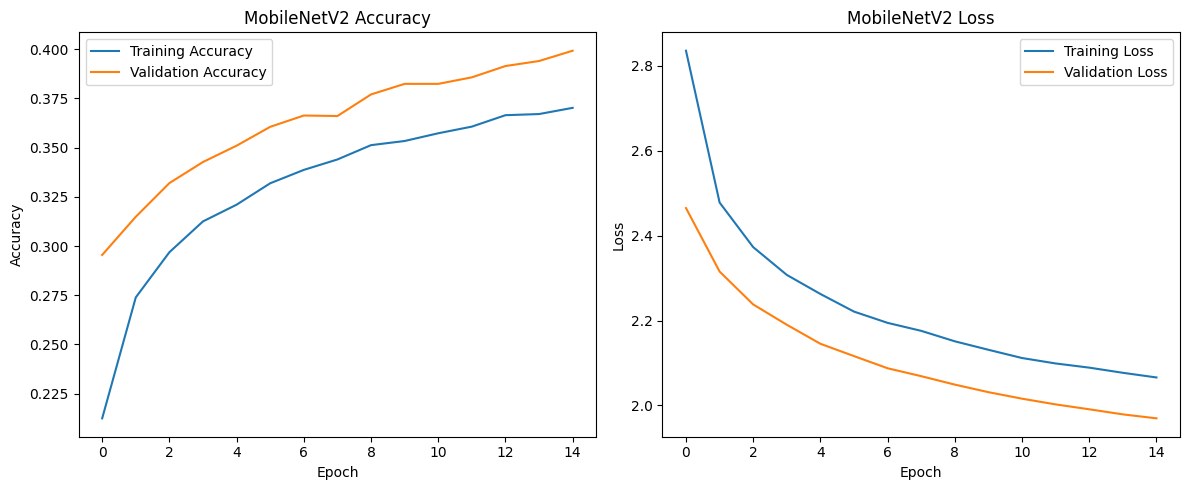

In [48]:
# Plot training accuracy and validation accuracy

plt.figure(figsize=(12,5))

# Accuracy graph

plt.subplot(1,2,1)

plt.plot(history_mobile.history['accuracy'],
         label='Training Accuracy')

plt.plot(history_mobile.history['val_accuracy'],
         label='Validation Accuracy')

plt.title("MobileNetV2 Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.legend()

# Loss graph

plt.subplot(1,2,2)

plt.plot(history_mobile.history['loss'],
         label='Training Loss')

plt.plot(history_mobile.history['val_loss'],
         label='Validation Loss')

plt.title("MobileNetV2 Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.legend()

plt.tight_layout()

plt.show()

## MobileNetV2 Training Observation

Training accuracy and validation accuracy improved gradually during training.

However, MobileNetV2 could not achieve performance comparable to the custom CNN model.

The validation accuracy reached approximately 39.91%.

# Make Predictions

In [49]:
# Predict validation images

y_pred_mobile = mobilenet_model.predict(X_val_mobile)

# Convert probabilities into class labels

y_pred_mobile_classes = np.argmax(y_pred_mobile,
                                  axis=1)

# Convert one-hot labels into original labels

y_true_mobile = np.argmax(y_val_mobile,
                          axis=1)

246/246 ━━━━━━━━━━━━━━━━━━━━ 12s 26ms/step


# Classification Report

In [50]:
from sklearn.metrics import classification_report

# Print classification report

print(classification_report(
    y_true_mobile,
    y_pred_mobile_classes
))

              precision    recall  f1-score   support

           0       1.00      0.17      0.29        42
           1       0.41      0.56      0.48       444
           2       0.29      0.29      0.29       450
           3       0.39      0.20      0.27       282
           4       0.34      0.22      0.27       396
           5       0.34      0.40      0.37       372
           6       0.56      0.32      0.41        84
           7       0.29      0.28      0.29       288
           8       0.27      0.19      0.22       282
           9       0.41      0.45      0.43       294
          10       0.33      0.47      0.39       402
          11       0.26      0.33      0.29       264
          12       0.39      0.77      0.52       420
          13       0.62      0.80      0.70       432
          14       0.51      0.54      0.53       156
          15       0.79      0.57      0.66       126
          16       0.58      0.23      0.32        84
          17       0.66    

## Confusion Matrix

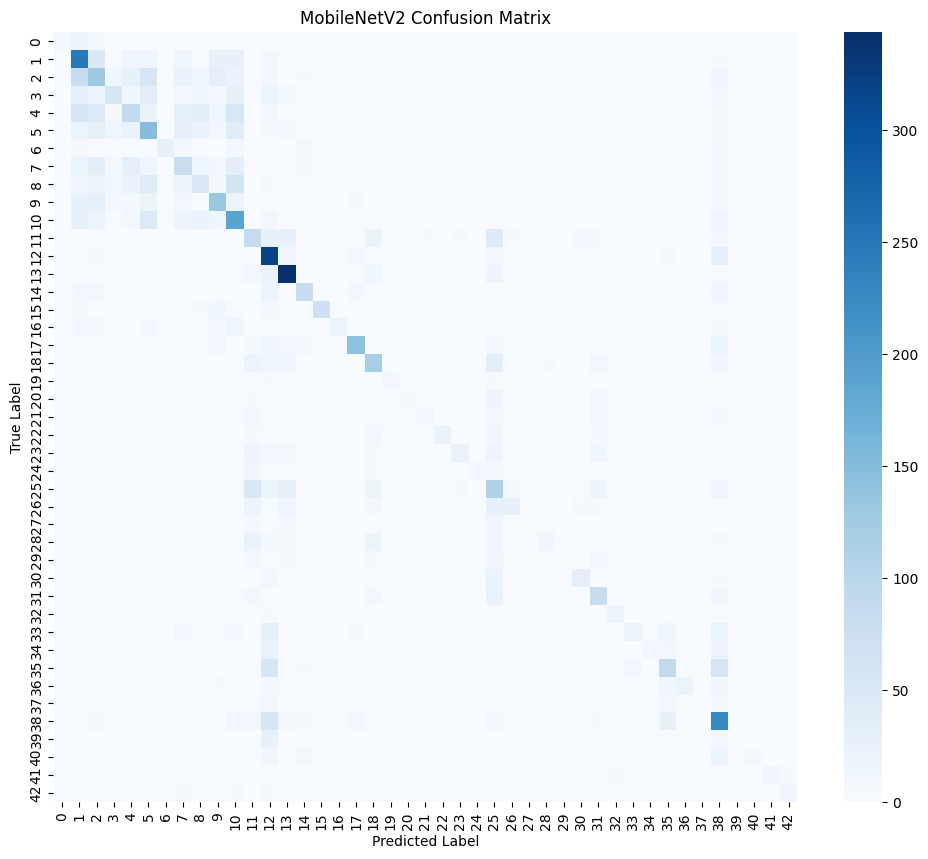

In [51]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

# Create confusion matrix

cm_mobile = confusion_matrix(
    y_true_mobile,
    y_pred_mobile_classes
)

# Plot confusion matrix

plt.figure(figsize=(12,10))

sns.heatmap(cm_mobile,
            cmap="Blues")

plt.title("MobileNetV2 Confusion Matrix")

plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.show()

## MobileNetV2 Performance Observation

MobileNetV2 achieved lower accuracy compared to the custom CNN model.

Due to the small image size and dataset characteristics, the transfer learning model was unable to outperform the CNN model.

Therefore, CNN was selected as the final model for this project.

# Save MobileNetV2 Model

In [52]:
# Save MobileNetV2 model

mobilenet_model.save(
"/content/drive/MyDrive/Traffic_Sign_Project/Traffic_Sign_Project/mobilenet_model.keras"
)

print("MobileNetV2 model saved successfully")

MobileNetV2 model saved successfully


# Model Comparison

Two deep learning models were implemented and compared.

The custom CNN and MobileNetV2 models were evaluated based on validation accuracy.

The best-performing model was selected for deployment.

In [53]:
# Create a dictionary for model comparison

comparison = {
    "Model": ["CNN", "MobileNetV2"],
    "Validation Accuracy": [99.39, 39.91]
}

# Convert dictionary into dataframe

comparison_df = pd.DataFrame(comparison)

# Display table

comparison_df

,Model,Validation Accuracy
0,CNN,99.39
1,MobileNetV2,39.91


# Plot Accuracy Comparison

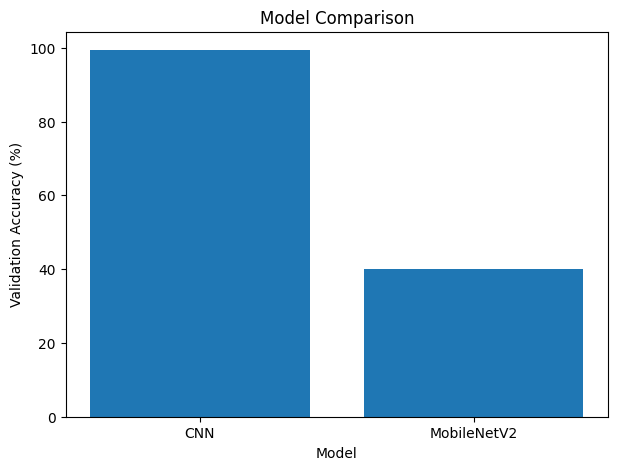

In [54]:
# Plot model comparison graph

plt.figure(figsize=(7,5))

plt.bar(
    comparison_df["Model"],
    comparison_df["Validation Accuracy"]
)

plt.title("Model Comparison")

plt.xlabel("Model")

plt.ylabel("Validation Accuracy (%)")

plt.show()

## Model Comparison Observation

Two deep learning models were implemented and evaluated.

The custom CNN achieved a validation accuracy of approximately 99.39%, whereas MobileNetV2 achieved about 39.91%.

The CNN model significantly outperformed MobileNetV2.

Therefore, CNN was selected as the final model for this project.

# Save Best Model

In [55]:
# Save best model

cnn_model.save(
"/content/drive/MyDrive/Traffic_Sign_Project/Traffic_Sign_Project/best_model.keras"
)

print("Best model saved successfully")

Best model saved successfully


# Best Model Selection

The custom CNN model achieved the highest validation accuracy.

It also demonstrated excellent precision, recall, and F1-score across all classes.

Therefore, the CNN model was selected as the final model for future predictions and deployment.

# Conclusion

The objective of this project was to classify traffic signs using deep learning techniques.

Exploratory Data Analysis (EDA) was performed to understand the dataset characteristics.

Images were resized and normalized before training.

Two deep learning models were implemented:

1. Custom CNN
2. MobileNetV2

The CNN model achieved approximately 99.39% validation accuracy and outperformed MobileNetV2.

Precision, recall, and F1-score were also close to 0.99, indicating balanced performance across different classes.

Therefore, the CNN model was selected as the final model for deployment.

This project demonstrates the effectiveness of convolutional neural networks for traffic sign classification tasks.

# Future Scope

Future improvements may include:

- Using larger image sizes.
- Applying data augmentation techniques.
- Fine-tuning transfer learning models.
- Experimenting with EfficientNet and ResNet architectures.
- Deploying the model using Streamlit.
- Building a real-time traffic sign recognition system.